In [0]:
%python
import requests
import pandas as pd

url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 41.88,
    "longitude": -87.63,
    "start_date": "2013-01-01",
    "end_date": "2013-12-31",
    "daily": "temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max",
    "temperature_unit": "fahrenheit",
    "wind_speed_unit": "mph",
    "precipitation_unit": "inch",
    "timezone": "America/Chicago"
}

response = requests.get(url, params=params)
print(f"Status: {response.status_code}")

Status: 200


In [0]:
%python
weather_json = response.json()

chicago = pd.DataFrame({
    "date":          weather_json["daily"]["time"],
    "temp_max_f":    weather_json["daily"]["temperature_2m_max"],
    "temp_min_f":    weather_json["daily"]["temperature_2m_min"],
    "precip_inches": weather_json["daily"]["precipitation_sum"],
    "wind_max_mph":  weather_json["daily"]["wind_speed_10m_max"]
})

chicago["date"]  = pd.to_datetime(chicago["date"])
chicago["month"] = chicago["date"].dt.month

print(f"Rows: {len(chicago)}")
display(chicago.head(10))

Rows: 365


date,temp_max_f,temp_min_f,precip_inches,wind_max_mph,month
2013-01-01T00:00:00.000Z,23.4,16.1,0.0,11.7,1
2013-01-02T00:00:00.000Z,27.4,12.5,0.0,12.9,1
2013-01-03T00:00:00.000Z,29.6,21.1,0.0,13.6,1
2013-01-04T00:00:00.000Z,35.0,18.2,0.0,19.9,1
2013-01-05T00:00:00.000Z,37.0,25.8,0.035,16.4,1
2013-01-06T00:00:00.000Z,33.9,26.6,0.0,15.6,1
2013-01-07T00:00:00.000Z,37.3,23.1,0.0,18.8,1
2013-01-08T00:00:00.000Z,38.0,29.1,0.0,18.4,1
2013-01-09T00:00:00.000Z,43.9,31.4,0.0,18.8,1
2013-01-10T00:00:00.000Z,39.5,28.8,0.315,14.3,1


temp_max_f,temp_min_f,precip_inches,wind_max_mph,month
365.0,365.0,365.0,365.0,365.0
53.7,43.0,0.1,14.3,6.5
20.2,20.4,0.2,4.3,3.5
11.7,-2.5,0.0,6.1,1.0
35.0,25.1,0.0,11.1,4.0
53.4,41.6,0.0,13.9,7.0
72.3,63.0,0.1,17.2,10.0
89.9,79.3,2.0,29.2,12.0


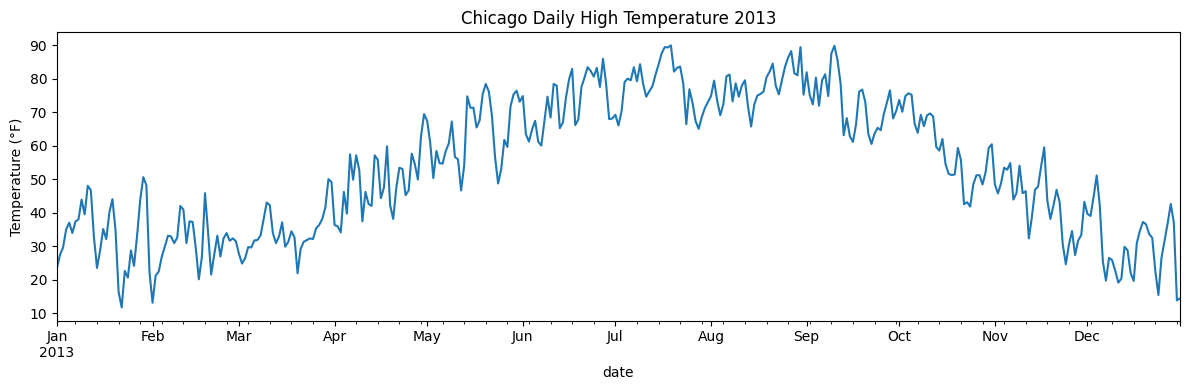

In [0]:
%python
display(chicago.select_dtypes(include="number").describe().round(1))
import matplotlib.pyplot as plt

# Daily high temperature over the year
chicago.plot(x="date", y="temp_max_f", figsize=(12, 4),
             title="Chicago Daily High Temperature 2013", legend=False)
plt.ylabel("Temperature (°F)")
plt.tight_layout()
plt.show()

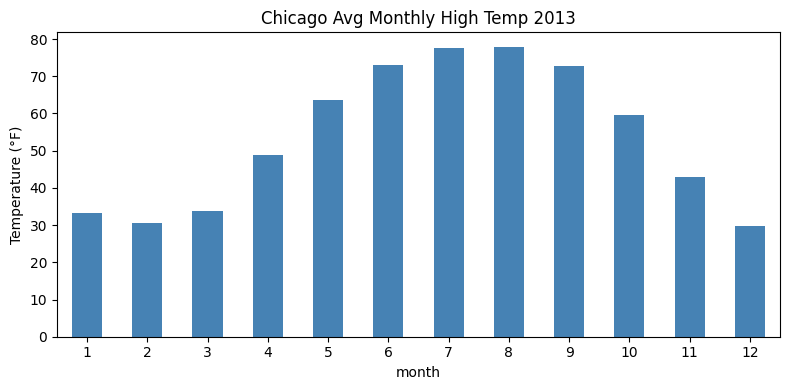

In [0]:
%python
monthly = chicago.groupby("month")["temp_max_f"].mean().round(1)

monthly.plot.bar(figsize=(8, 4), title="Chicago Avg Monthly High Temp 2013", color="steelblue")
plt.ylabel("Temperature (°F)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [0]:
%python
chicago_spark = spark.createDataFrame(chicago)
chicago_spark.write.mode("overwrite").option("overwriteSchema", "true").saveAsTable("chicago_weather")
print("Table saved: chicago_weather")

Table saved: chicago_weather


In [0]:
SELECT
    c.month,
    ROUND(AVG(c.temp_max_f), 1) AS chicago_avg_high,
    ROUND(AVG(c.temp_min_f), 1) AS chicago_avg_low,
    ROUND(AVG(n.temp_max_f), 1) AS nyc_avg_high,
    ROUND(AVG(n.temp_min_f), 1) AS nyc_avg_low
FROM chicago_weather c
JOIN nyc_weather n ON c.month = MONTH(n.date)
GROUP BY c.month
ORDER BY c.month

month,chicago_avg_high,chicago_avg_low,nyc_avg_high,nyc_avg_low
1,33.3,21.7,39.7,26.0
2,30.6,19.2,37.4,23.3
3,33.9,23.0,44.7,30.4
4,48.7,36.7,59.3,40.9
5,63.6,52.2,69.8,51.1
6,72.9,62.7,78.4,62.5
7,77.7,68.2,84.3,71.1
8,77.9,67.5,79.6,64.6
9,72.7,62.2,73.7,56.9
10,59.5,49.1,65.2,50.4


In [0]:
%python


daily = spark.sql("""
    SELECT
        MAKE_DATE(f.year, f.month, f.day) AS flight_date,
        ROUND(AVG(f.arr_delay), 2)        AS avg_delay,
        MAX(w.temp_max_f)                 AS temp_max,
        MAX(w.precip_inches)              AS precip,
        MAX(w.wind_max_mph)               AS wind
    FROM flights f
    JOIN nyc_weather w ON MAKE_DATE(f.year, f.month, f.day) = w.date
    WHERE f.arr_delay IS NOT NULL
    GROUP BY flight_date
    ORDER BY flight_date
""").toPandas()

display(daily.head())

flight_date,avg_delay,temp_max,precip,wind
2013-01-01,12.65,37.3,0.0,11.9
2013-01-02,12.69,30.1,0.0,10.1
2013-01-03,5.73,30.5,0.0,8.7
2013-01-04,-1.93,35.7,0.0,13.5
2013-01-05,-1.53,39.1,0.0,11.2


In [0]:
%python
correlations = daily[["avg_delay", "temp_max", "precip", "wind"]].corr()
display(correlations.round(3))

avg_delay,temp_max,precip,wind
1.0,0.05,0.488,0.189
0.05,1.0,0.032,-0.313
0.488,0.032,1.0,0.266
0.189,-0.313,0.266,1.0


In [0]:
%python
worst5 = daily.sort_values("avg_delay", ascending=False).head(5)
display(worst5[["flight_date", "avg_delay", "temp_max", "precip", "wind"]])

flight_date,avg_delay,temp_max,precip,wind
2013-03-08,85.86,38.0,0.39,13.9
2013-06-13,63.75,64.5,1.224,16.8
2013-07-22,62.76,82.7,0.213,7.1
2013-05-23,61.97,76.2,0.618,11.6
2013-07-10,59.63,83.1,0.693,11.3


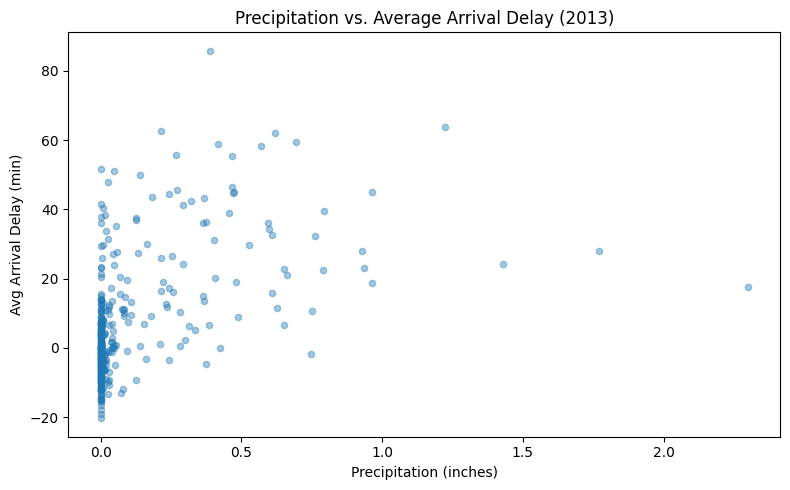

In [0]:
%python
import matplotlib.pyplot as plt

daily.plot.scatter(x="precip", y="avg_delay", figsize=(8, 5), alpha=0.4)
plt.title("Precipitation vs. Average Arrival Delay (2013)")
plt.xlabel("Precipitation (inches)")
plt.ylabel("Avg Arrival Delay (min)")
plt.tight_layout()
plt.show()

In [0]:
%python
df = (spark.read
          .option("header", True)
          .option("inferSchema", True)
          .csv("/Volumes/personal_data/default/happiness_15-19/2019.csv"))

display(df.limit(10))

Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
1,Finland,7.769,1.34,1.587,0.986,0.596,0.153,0.393
2,Denmark,7.6,1.383,1.573,0.996,0.592,0.252,0.41
3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
4,Iceland,7.494,1.38,1.624,1.026,0.591,0.354,0.118
5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298
6,Switzerland,7.48,1.452,1.526,1.052,0.572,0.263,0.343
7,Sweden,7.343,1.387,1.487,1.009,0.574,0.267,0.373
8,New Zealand,7.307,1.303,1.557,1.026,0.585,0.33,0.38
9,Canada,7.278,1.365,1.505,1.039,0.584,0.285,0.308
10,Austria,7.246,1.376,1.475,1.016,0.532,0.244,0.226


In [0]:
%python
import pandas as pd

# ── Load directly into pandas ─────────────────────────────────────────────────
df = pd.read_csv("/Volumes/personal_data/default/happiness_15-19/2019.csv")
# ── Explore ───────────────────────────────────────────────────────────────────
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nDescribe:\n", df.describe().round(3))
df.head()

Shape: (156, 9)

Dtypes:
 Overall rank                      int64
Country or region                object
Score                           float64
GDP per capita                  float64
Social support                  float64
Healthy life expectancy         float64
Freedom to make life choices    float64
Generosity                      float64
Perceptions of corruption       float64
dtype: object

Describe:
        Overall rank    Score  ...  Generosity  Perceptions of corruption
count       156.000  156.000  ...     156.000                    156.000
mean         78.500    5.407  ...       0.185                      0.111
std          45.177    1.113  ...       0.095                      0.095
min           1.000    2.853  ...       0.000                      0.000
25%          39.750    4.544  ...       0.109                      0.047
50%          78.500    5.380  ...       0.178                      0.085
75%         117.250    6.184  ...       0.248                      0.141
max 

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


In [0]:
%python
# Clean column names first
df.columns = (df.columns
                .str.strip()
                .str.lower()
                .str.replace(r"[^\w]", "_", regex=True)
                .str.replace(r"_+", "_", regex=True)
                .str.strip("_"))

print("Columns now:", df.columns.tolist())

# Then save
spark_df = spark.createDataFrame(df)
spark_df.write.mode("overwrite").option("overwriteSchema", "true").saveAsTable("happiness_2019")
print("Table saved: happiness_2019")

Columns now: ['overall_rank', 'country_or_region', 'score', 'gdp_per_capita', 'social_support', 'healthy_life_expectancy', 'freedom_to_make_life_choices', 'generosity', 'perceptions_of_corruption']
Table saved: happiness_2019


In [0]:
-- ── Query 1: FILTER — countries with a happiness score above 7.0 ─────────────

SELECT country_or_region, 
score, 
gdp_per_capita, 
healthy_life_expectancy
FROM happiness_2019
WHERE score > 7.0
ORDER BY score DESC

country_or_region,score,gdp_per_capita,healthy_life_expectancy
Finland,7.769,1.34,0.986
Denmark,7.6,1.383,0.996
Norway,7.554,1.488,1.028
Iceland,7.494,1.38,1.026
Netherlands,7.488,1.396,0.999
Switzerland,7.48,1.452,1.052
Sweden,7.343,1.387,1.009
New Zealand,7.307,1.303,1.026
Canada,7.278,1.365,1.039
Austria,7.246,1.376,1.016


In [0]:
select
country_or_region,
avg(score) as avg_score
from happiness_2019
group by country_or_region


country_or_region,avg_score
Finland,7.769
Denmark,7.6
Norway,7.554
Iceland,7.494
Netherlands,7.488
Switzerland,7.48
Sweden,7.343
New Zealand,7.307
Canada,7.278
Austria,7.246


In [0]:
select
country_or_region,
score,
round(score - lag(score,1) over (order by score),2) as difference_curr_prev_score
from happiness_2019

country_or_region,score,difference_curr_prev_score
South Sudan,2.853,null
Central African Republic,3.083,0.23
Afghanistan,3.203,0.12
Tanzania,3.231,0.03
Rwanda,3.334,0.1
Yemen,3.38,0.05
Malawi,3.41,0.03
Syria,3.462,0.05
Botswana,3.488,0.03
Haiti,3.597,0.11


In [0]:
SELECT
    *,
    RANK() OVER (ORDER BY social_support DESC) AS rank_happiness_socialsupport
FROM happiness_2019
ORDER BY rank_happiness_socialsupport

overall_rank,country_or_region,score,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption,rank_happiness_socialsupport
4,Iceland,7.494,1.38,1.624,1.026,0.591,0.354,0.118,1
1,Finland,7.769,1.34,1.587,0.986,0.596,0.153,0.393,2
3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341,3
2,Denmark,7.6,1.383,1.573,0.996,0.592,0.252,0.41,4
8,New Zealand,7.307,1.303,1.557,1.026,0.585,0.33,0.38,5
16,Ireland,7.021,1.499,1.553,0.999,0.516,0.298,0.31,6
11,Australia,7.228,1.372,1.548,1.036,0.557,0.332,0.29,7
87,Turkmenistan,5.247,1.052,1.538,0.657,0.394,0.244,0.028,8
15,United Kingdom,7.054,1.333,1.538,0.996,0.45,0.348,0.278,8
83,Mongolia,5.285,0.948,1.531,0.667,0.317,0.235,0.038,10
